# Лабораторная работа №1
## Обработка признаков (Feature Engineering)

**Студент:** Каунг Хтет Вин  
**Группа:** ИУ5И-23М  
**Датасет:** Titanic (sns.load_dataset)

**Цель работы:** Изучение продвинутых способов предварительной обработки данных для дальнейшего формирования моделей.

**Задачи:**
1. Устранение пропусков в данных
2. Кодирование категориальных признаков
3. Нормализация числовых признаков

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ")
print("="*60)

БИБЛИОТЕКИ УСПЕШНО ЗАГРУЖЕНЫ


In [2]:
# Загрузка данных Titanic
df = sns.load_dataset('titanic')

print("="*60)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ TITANIC")
print("="*60)
print(f"\nРазмер датасета: {df.shape[0]} строк x {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
df.head()

ИНФОРМАЦИЯ О ДАТАСЕТЕ TITANIC

Размер датасета: 891 строк x 15 столбцов

Первые 5 строк:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


ПРОПУСКИ В ДАННЫХ ДО ОБРАБОТКИ
             Количество пропусков    Процент
age                           177  19.865320
embarked                        2   0.224467
deck                          688  77.216611
embark_town                     2   0.224467


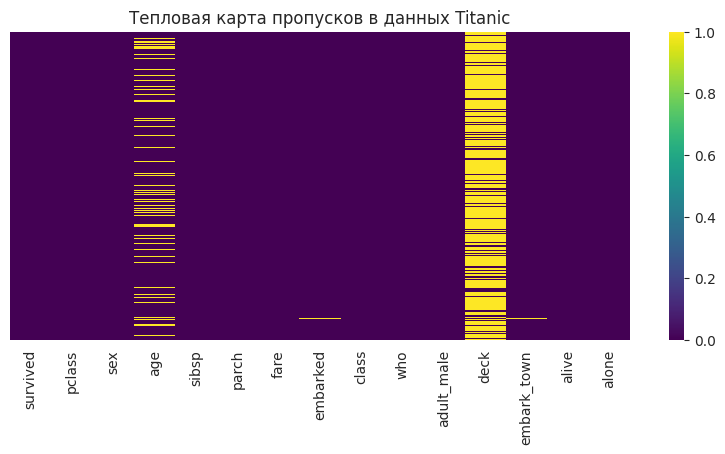

In [3]:
print("="*60)
print("ПРОПУСКИ В ДАННЫХ ДО ОБРАБОТКИ")
print("="*60)

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing_counts, 'Процент': missing_percent})
missing_df = missing_df[missing_df['Количество пропусков'] > 0]
print(missing_df)

# Визуализация пропусков
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Тепловая карта пропусков в данных Titanic')
plt.show()

In [6]:
print("="*60)
print("ЗАДАЧА 1: УСТРАНЕНИЕ ПРОПУСКОВ В ДАННЫХ")
print("="*60)

df_cleaned = df.copy()

# 1.1 age - заполнение медианой
median_age = df_cleaned['age'].median()
df_cleaned['age_filled'] = df_cleaned['age'].fillna(median_age)
print(f"✓ age: Заполнено медианой = {median_age} (пропусков было: {df['age'].isnull().sum()})")

# 1.2 embarked - заполнение модой
mode_embarked = df_cleaned['embarked'].mode()[0]
df_cleaned['embarked_filled'] = df_cleaned['embarked'].fillna(mode_embarked)
print(f"✓ embarked: Заполнено модой = '{mode_embarked}' (пропусков было: {df['embarked'].isnull().sum()})")

# 1.3 deck - ПРЕОБРАЗУЕМ В STRING ПЕРЕД ЗАПОЛНЕНИЕМ
df_cleaned['deck_filled'] = df_cleaned['deck'].astype(str).fillna('Unknown')
print(f"✓ deck: Заполнено категорией 'Unknown' (пропусков было: {df['deck'].isnull().sum()})")

print("\nРЕЗУЛЬТАТ: ПРОПУСКОВ НЕТ")
print(df_cleaned[['age_filled', 'embarked_filled', 'deck_filled']].isnull().sum())

ЗАДАЧА 1: УСТРАНЕНИЕ ПРОПУСКОВ В ДАННЫХ
✓ age: Заполнено медианой = 28.0 (пропусков было: 177)
✓ embarked: Заполнено модой = 'S' (пропусков было: 2)
✓ deck: Заполнено категорией 'Unknown' (пропусков было: 688)

РЕЗУЛЬТАТ: ПРОПУСКОВ НЕТ
age_filled         0
embarked_filled    0
deck_filled        0
dtype: int64


In [7]:
print("="*60)
print("ЗАДАЧА 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)

# 2.1 Label Encoding для 'class'
le_class = LabelEncoder()
df_cleaned['class_encoded'] = le_class.fit_transform(df_cleaned['class'])
print(f"✓ class: Label Encoding -> {dict(zip(le_class.classes_, le_class.transform(le_class.classes_)))}")

# 2.2 One-Hot Encoding для 'sex'
sex_onehot = pd.get_dummies(df_cleaned['sex'], prefix='sex', dtype=int)
df_cleaned = pd.concat([df_cleaned, sex_onehot], axis=1)
print(f"✓ sex: One-Hot Encoding -> создано {sex_onehot.shape[1]} столбцов")

# 2.3 One-Hot Encoding для 'embarked_filled'
embarked_onehot = pd.get_dummies(df_cleaned['embarked_filled'], prefix='embarked', dtype=int)
df_cleaned = pd.concat([df_cleaned, embarked_onehot], axis=1)
print(f"✓ embarked_filled: One-Hot Encoding -> создано {embarked_onehot.shape[1]} столбцов")

# 2.4 Frequency Encoding для 'deck_filled'
deck_freq = df_cleaned['deck_filled'].value_counts(normalize=True)
df_cleaned['deck_freq_encoded'] = df_cleaned['deck_filled'].map(deck_freq)
print(f"✓ deck_filled: Frequency Encoding -> заменено на частоты")

print("\nРезультат кодирования (первые 5 строк):")
df_cleaned[['class_encoded', 'sex_male', 'sex_female', 'embarked_S', 'embarked_C', 'embarked_Q', 'deck_freq_encoded']].head()

ЗАДАЧА 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
✓ class: Label Encoding -> {'First': np.int64(0), 'Second': np.int64(1), 'Third': np.int64(2)}
✓ sex: One-Hot Encoding -> создано 2 столбцов
✓ embarked_filled: One-Hot Encoding -> создано 3 столбцов
✓ deck_filled: Frequency Encoding -> заменено на частоты

Результат кодирования (первые 5 строк):


,class_encoded,sex_male,sex_female,embarked_S,embarked_C,embarked_Q,deck_freq_encoded
0,2,1,0,1,0,0,0.772166
1,0,0,1,0,1,0,0.066218
2,2,0,1,1,0,0,0.772166
3,0,0,1,1,0,0,0.066218
4,2,1,0,1,0,0,0.772166


In [10]:
print("="*60)
print("ЗАДАЧА 3: НОРМАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*60)

# 3.1 Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_cleaned['age_minmax'] = scaler_minmax.fit_transform(df_cleaned[['age_filled']])

# 3.2 Standardization (Z-score)
scaler_std = StandardScaler()
df_cleaned['age_standardized'] = scaler_std.fit_transform(df_cleaned[['age_filled']])

print("Min-Max Normalization:")
print(f"  До: min={df_cleaned['age_filled'].min():.2f}, max={df_cleaned['age_filled'].max():.2f}")
print(f"  После: min={df_cleaned['age_minmax'].min():.2f}, max={df_cleaned['age_minmax'].max():.2f}")

print("\nStandardization (Z-score):")
print(f"  До: mean={df_cleaned['age_filled'].mean():.2f}, std={df_cleaned['age_filled'].std():.2f}")
print(f"  После: mean={df_cleaned['age_standardized'].mean():.10f}, std={df_cleaned['age_standardized'].std():.6f}")



ЗАДАЧА 3: НОРМАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
Min-Max Normalization:
  До: min=0.42, max=80.00
  После: min=0.00, max=1.00

Standardization (Z-score):
  До: mean=29.36, std=13.02
  После: mean=0.0000000000, std=1.000562


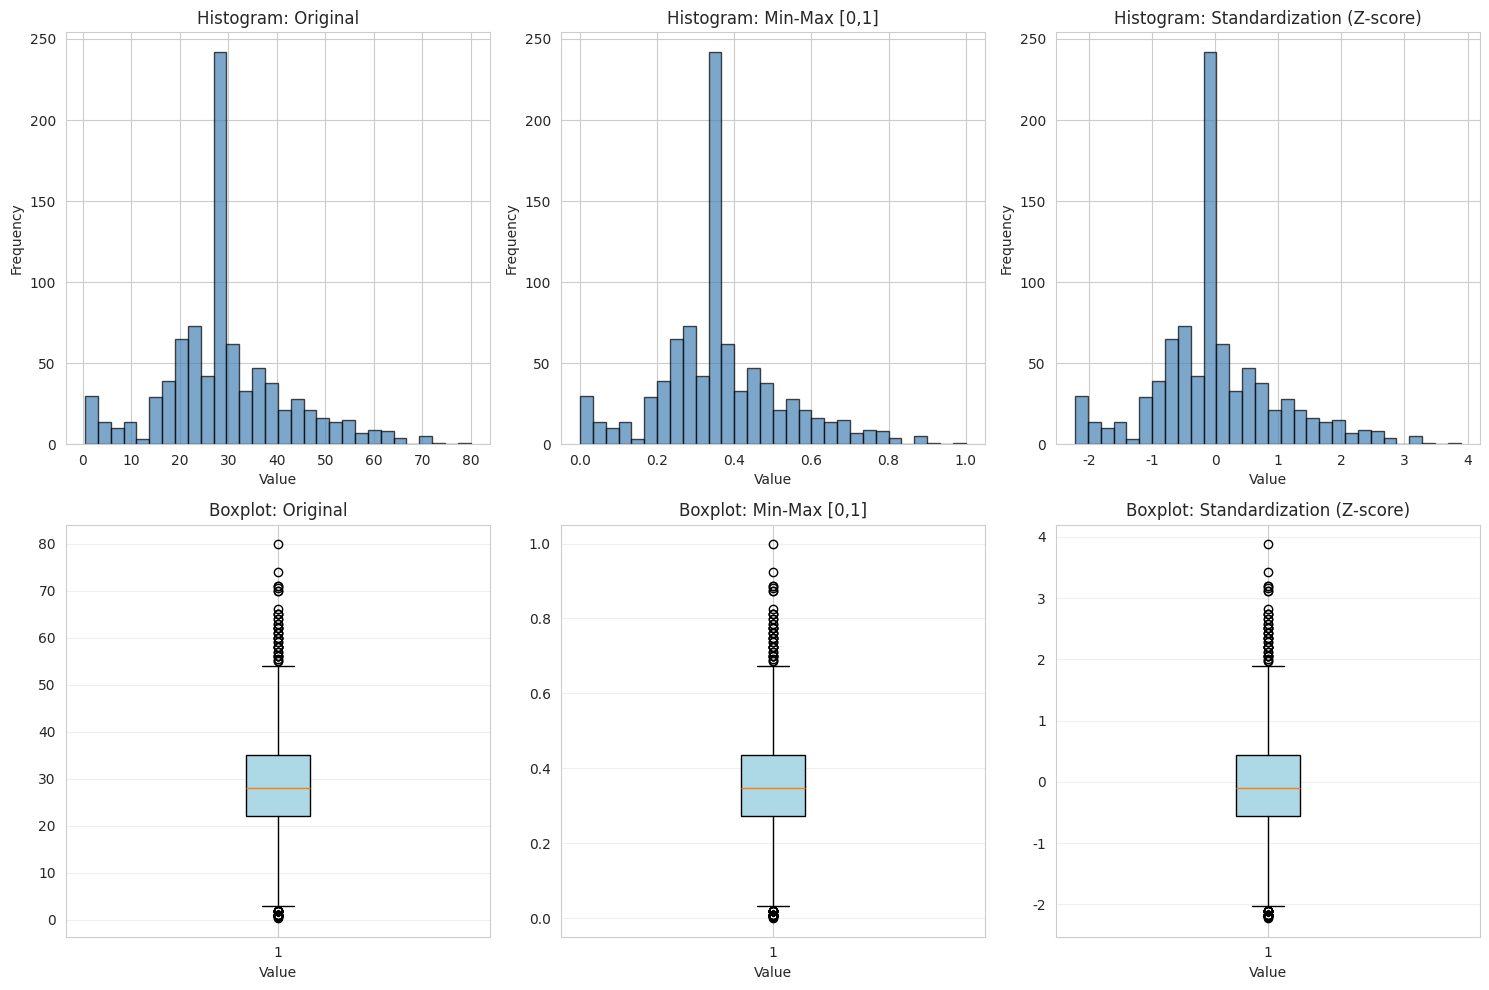

In [11]:
# 3.3 Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['age_filled', 'age_minmax', 'age_standardized']
titles = ['Original', 'Min-Max [0,1]', 'Standardization (Z-score)']

for i, (feature, title) in enumerate(zip(features_to_plot, titles)):
    # Гистограмма
    axes[0, i].hist(df_cleaned[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'Histogram: {title}', fontsize=12)
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')

    # Boxplot
    axes[1, i].boxplot(df_cleaned[feature].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
    axes[1, i].set_title(f'Boxplot: {title}', fontsize=12)
    axes[1, i].set_xlabel('Value')
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## ВЫВОД

В ходе выполнения лабораторной работы был проведен комплексный анализ и обработка данных на основе набора данных Titanic.

### Выполнены следующие задачи:

| № | Задача | Метод | Результат |
|---|--------|-------|-----------|
| 1 | Устранение пропусков | Медиана (age), Мода (embarked), 'Unknown' (deck) | Все пропуски устранены |
| 2 | Кодирование категориальных признаков | Label, One-Hot, Frequency Encoding | Признаки преобразованы в числовой формат |
| 3 | Нормализация числовых признаков | Min-Max, Standardization (Z-score) | Данные масштабированы для моделей |

### Выводы:
1. **Пропуски** были успешно обработаны без потери информации
2. **Категориальные признаки** закодированы с учетом их природы (номинативные/порядковые)
3. **Нормализация** сохранила форму распределения, изменив только масштаб